# Building a Transformer Encoder for Text Classification
## 1 - Introduction
In this notebook, you'll build a **Transformer Encoder** from scratch and apply it to sentiment analysis—classifying movie reviews as positive or negative. 

Attention on its own isn't enough to build a transformer model. You're going to use bigger building blocks like an encoder block. And you can think of this as a mini pipeline. These layers are what you're going to actually stack and train.

### What is a Transformer Encoder?
A Transformer encoder is a neural network architecture that transforms input text into rich numerical representations. It reads an entire sequence of words at once and produces a contextualized representation for each word—meaning each word's representation contains information about how it relates to all other words in the sequence. Think of it as a sophisticated reading comprehension system that understands not just individual words, but their meanings in context.

This hands-on implementation will deepen your understanding of how encoder models work and why they've become the backbone of models like BERT, RoBERTa, and other state-of-the-art NLP systems.

### What You'll Build
Starting from the attention mechanisms you've already mastered, you'll construct:
1. A complete encoder block with multi-head attention and feed-forward layers
2. A stack of encoder layers that progressively refine text representations
3. A classification head that uses these representations for sentiment analysis
4. A training pipeline that achieves strong performance on real movie reviews

By the end of this notebook, you'll have implemented the same encoder architecture that, when pre-trained on massive text corpora, becomes BERT—one of the most important breakthroughs in modern NLP.

### 1.1 Importing Necessary Modules

In [1]:
import math
import random
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import helper_utils

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

## 2 - Building the Encoder Block
### 2.1 Understanding the Encoder Architecture

The encoder block is the fundamental building block of the Transformer encoder—a sophisticated text processing unit that refines word representations through attention and feed-forward mechanisms.

<div align="center">
  <img src="../../../../images/PyTorch/encoder-block.svg" alt="Encoder Block Architecture" width="80%">
</div>

#### Key Components

**Multi-Head Attention**: Allows every word to gather information from all other words, with multiple parallel attention heads learning different types of relationships.

**Feed-Forward Network**: Applies the same neural network independently to each position, adding non-linearity through two linear layers with ReLU activation.

**Residual Connections** (green dashed lines): Create a direct path from input to output by adding the original input to each sub-layer's output. This preserves information and enables gradient flow through deep networks. Mathematically: `Output = Input + SubLayer(Input)`

**Layer Normalization**: Stabilizes training by normalizing activations before each sub-layer.

As you stack encoder layers, a token's representation gets updated again and again. Over time, some dimensions can blow up while others shrink, making learning harder. Normalization keeps that scale balanced so your training stays stable. That way, no matter how many encoder layers you stack, each one will start from a balanced input that's easier for the model to learn from. But fixed normalization can be too rigid. If every token's vector is always forced to have a mean zero and a variance one across its dimensions, you risk wiping out useful differences that the model might want to preserve. And maybe some dimensions should consistently vary more than others or maybe carry a small bias. And that's why layer normalization adds learnable scale and shift parameters, giving each dimension its own simple linear adjustment. This way, normalization keeps things balanced while the model can still emphasize or de-emphasize features as needed.

What comes out is a new set of token representations, with each one being updated by attending to the others. But if you only use that output and threw away the originals, you might lose information that the token already carried. So let's add a residual connection, just like you saw with ResNets. The attention output is added back to the input, so each token keeps what it already had, plus the information that it learned from attention. After attention and a residual connection, the tokens are now richer, but they're also on a new scale. So if you feed them straight into the next layer, those values could be uneven again, just like they were at the start. Therefore, before you feed forward network, you often add another layer normalization. It will rebalance the token features so that the next transformation starts from a stable input. So far, attention has mixed information across tokens. Each token now carries context from the others. But attention alone doesn't give the model much power to transform each token's features on its own. And that's why every encoder block also includes that feed-forward network. It's simple. Two linear layers with an activation in between. We've seen layers like this before. This step adds extra capacity and non-linearity, so the model can refine each token's representation in richer ways. And as always, a residual connection wraps around it, so the token keeps what it had before while gaining this new transformation.

### 2.2 Implementing the Encoder Block

Let's implement the encoder block, bringing together all these components into a modular unit that can be stacked to create increasingly sophisticated representations. Each additional layer captures more abstract patterns and longer-range dependencies.

**Note:** This is a simplified version of an Encoder Layer. PyTorch's implementation includes additional parameters for more flexibility.

In [2]:
class EncoderBlock(nn.Module):
    """
    A single layer of a Transformer encoder.

    Args:
        d_model: The number of expected features in the input.
        nhead: The number of heads in the multi-head attention mechanism.
        ffn_mult: The multiplier used to determine the hidden layer size of the feed-forward network.
    """
    def __init__(self, d_model=4, nhead=1, ffn_mult=4):
        """
        Initializes the components of the encoder block.

        Args:
            d_model: The dimensionality of the input embeddings.
            nhead: The number of attention heads.
            ffn_mult: Expansion factor for the internal feed-forward layer.
        """
        super().__init__()
        # Normalization layer applied prior to the attention sub-layer
        self.ln1 = nn.LayerNorm(d_model)
        # Multi-head attention module for calculating contextual representations
        self.mha = nn.MultiheadAttention(d_model, nhead, batch_first=True)
        # Normalization layer applied prior to the feed-forward sub-layer
        self.ln2 = nn.LayerNorm(d_model)        
        # Calculate the dimensionality of the internal hidden layer
        hidden = ffn_mult * d_model
        # Sequential network providing non-linear transformations for each position
        self.ffn = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.ReLU(),
            nn.Linear(hidden, d_model)
        )
    
    def forward(self, x):        
        """
        Processes the input sequence through the encoder block sub-layers.

        Args:
            x: The input tensor of shape [batch_size, sequence_length, d_model].

        Returns:
            The processed tensor after self-attention and feed-forward transformations.
        """
        # Apply normalization to the input sequence
        x_norm = self.ln1(x)
        # Compute self-attention and capture the output vectors
        attn_out, _ = self.mha(x_norm, x_norm, x_norm)
        # Add the attention output to the original input for the first residual connection
        x = x + attn_out
        
        # Apply normalization to the output of the first sub-layer
        ffn_in = self.ln2(x)
        # Pass the normalized data through the feed-forward network
        ffn_out = self.ffn(ffn_in)
        # Add the feed-forward output to its input for the second residual connection
        x = x + ffn_out
        
        # Return the resulting contextualized representations
        return x

### 2.3 Testing the Encoder Block
Let's create a simple example to understand how the encoder block transforms input data. You'll create a small input tensor and pass it through the encoder to see the output shape and values.

In [3]:
# Create a simple encoder block with small dimensions for demonstration
encoder_demo = EncoderBlock(d_model=4, nhead=1, ffn_mult=4)

# Create a sample input: (batch_size=2, sequence_length=3, d_model=4)
sample_input = torch.randn(2, 3, 4)

print("Input shape:", sample_input.shape)
print("Input tensor:\n", sample_input)

# Pass through encoder block
output = encoder_demo(sample_input)

print("\nOutput shape:", output.shape)
print("Output tensor:\n", output)

# Notice that the shape remains the same
print("\nShape preserved: Input shape == Output shape:", sample_input.shape == output.shape)

Input shape: torch.Size([2, 3, 4])
Input tensor:
 tensor([[[ 1.3032,  0.4879,  1.1340, -0.3556],
         [ 0.3618,  1.9993,  0.6630,  0.7047],
         [-0.9291,  0.2762, -0.5389,  0.4626]],

        [[-0.8719, -0.0271, -0.3532,  1.4639],
         [ 1.2554, -0.7150,  0.8539,  0.5130],
         [ 0.5397,  0.5655,  0.5058,  0.2225]]])

Output shape: torch.Size([2, 3, 4])
Output tensor:
 tensor([[[ 1.0026,  0.2121,  1.4273,  0.1655],
         [ 0.4462,  1.7480,  0.8359,  1.2673],
         [-0.9382, -0.1464, -0.3801,  0.8587]],

        [[-0.8144, -0.2512, -0.4787,  1.6496],
         [ 0.5040, -1.2128,  0.8961,  0.6108],
         [ 0.3139,  0.4903,  0.5755,  0.6699]]], grad_fn=<AddBackward0>)

Shape preserved: Input shape == Output shape: True


### 2.4 Positional Encoding

#### The Problem: Attention is Position-Blind

Without positional information, attention treats input as an unordered bag of words. The sentences "The cat chased the dog" and "The dog chased the cat" would look identical to the model—just a set of words without sequence information.

#### The Solution: Adding Position Information

Positional encoding adds a unique "position signature" to each token's embedding, like GPS coordinates for words. This tells the model not just *what* each word is, but *where* it appears in the sequence.

<div align="center">
<img src="../../../../images/PyTorch/positional-encoding.svg" alt="Positional Encoding in Encoder" width="70%">
</div>

The encoder uses sinusoidal functions (sine and cosine waves at different frequencies) to create these position signatures:
- Each position gets a unique pattern—like a mathematical fingerprint
- The model can learn relative distances between any two positions
- Patterns naturally extend to sequences longer than training data

This enables the model to understand both **absolute position** ("3rd word") and **relative position** ("4 positions apart"), crucial for understanding grammar and long-range dependencies.

In [4]:
class PositionalEncoding(nn.Module):
    """
    Implements sinusoidal positional encoding to inject sequence order into token embeddings.
    """
    def __init__(self, max_len, d_model):
        """
        Initializes the positional encoding matrix with precomputed values.

        Args:
            max_len (int): The maximum sequence length supported by this module.
            d_model (int): The dimensionality of the encoding vectors, matching the embedding size.
        """
        super().__init__()
        # Store the maximum sequence length capacity
        self.max_len = max_len
        # Store the feature dimension of the model
        self.d_model = d_model
        
        # Initialize a tensor of zeros to hold the positional encodings
        pe = torch.zeros(max_len, d_model)
        # Generate a vector of token positions from 0 to max_len
        position = torch.arange(0, max_len).unsqueeze(1).float()
        
        # Calculate the divisor term used for scaling frequencies in the sinusoids
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                           -(torch.log(torch.tensor(10000.0)) / d_model))
        
        # Assign sine values to the even indices of the encoding matrix
        pe[:, 0::2] = torch.sin(position * div_term)
        # Assign cosine values to the odd indices of the encoding matrix
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # Register the matrix as a persistent buffer that is not considered a learnable parameter
        self.register_buffer('pe', pe.unsqueeze(0))
        
    def forward(self, x):
        """
        Retrieves the positional encodings corresponding to the current input sequence length.

        Args:
            x (Tensor): The input token embeddings with shape [batch_size, seq_len, d_model].
            
        Returns:
            pe_slice (Tensor): The positional encoding tensor of shape [batch_size, seq_len, d_model].
        """
        # Determine the length of the sequence based on the input tensor dimensions
        seq_len = x.size(1)
        # Extract and return the subset of the precomputed matrix matching the input length
        return self.pe[:, :seq_len, :]

Let's visualize how positional encoding works:

Input embeddings shape: torch.Size([2, 10, 128])
Input embeddings mean: 0.0051

Output shape (unchanged): torch.Size([1, 10, 128])
Output mean (slightly different): 0.4782


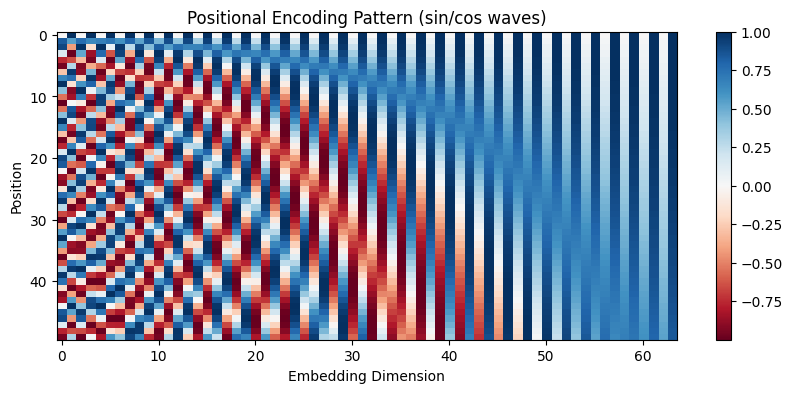

In [5]:
# Example: Create positional encoding and visualize
d_model = 128
max_len = 100
pos_encoder = PositionalEncoding(max_len=max_len, d_model=d_model)

# Create dummy embeddings for a batch of sequences
batch_size = 2
seq_len = 10
dummy_embeddings = torch.randn(batch_size, seq_len, d_model)

print(f"Input embeddings shape: {dummy_embeddings.shape}")
print(f"Input embeddings mean: {dummy_embeddings.mean():.4f}")

# Apply positional encoding
output = pos_encoder(dummy_embeddings)
print(f"\nOutput shape (unchanged): {output.shape}")
print(f"Output mean (slightly different): {output.mean():.4f}")

# Visualize the positional encoding pattern for first half of positions and dimensions
pe_matrix = pos_encoder.pe[0, :50, :64].numpy()
plt.figure(figsize=(10, 4))
plt.imshow(pe_matrix, cmap='RdBu', aspect='auto')
plt.colorbar()
plt.xlabel('Embedding Dimension')
plt.ylabel('Position')
plt.title('Positional Encoding Pattern (sin/cos waves)')
plt.show()

### Understanding the Positional Encoding Visualization

This heatmap shows the positional encoding values added to embeddings:

- **X-axis**: Embedding dimensions (0-63)
- **Y-axis**: Sequence positions (0-49)  
- **Colors**: Blue = positive values, Red = negative values, White = near zero

**Key Patterns**:
- **Left side**: Fast alternating patterns (high frequency) - capture local/nearby position information
- **Right side**: Smooth gradients (low frequency) - capture global/long-range position information
- **Each row**: Has a unique pattern - this is how position 5 is distinguished from position 45

The varying frequencies (fast to slow) allow the model to understand both local word relationships and long-distance dependencies in the sequence. Each position gets a unique "fingerprint" that the model learns to interpret.

### 2.5 Understanding Padding Masks in Transformers

#### What is Padding and Why Do We Need It?

In real-world NLP applications, sentences have varying lengths. To process them efficiently in batches, we need to make all sequences the same length by adding **padding tokens**. However, these padding tokens shouldn't contribute to our model's understanding of the actual text.

In [6]:
def create_padding_mask(seq, pad_idx=0):
    """
    Generates a boolean mask to identify padding tokens within a sequence.

    Args:
        seq (Tensor): Input sequence tensor of shape [batch_size, seq_len].
        pad_idx (int): The specific integer index used to represent padding.

    Returns:
        mask (Tensor): A boolean tensor of the same shape as the input, where 
                       True represents a padding token and False represents a 
                       valid token.
    """
    # Compare each element in the sequence to the padding index to create a boolean map
    return seq == pad_idx

In [7]:
# Example usage
# Sample batch with padding
batch = torch.tensor([
    [2, 15, 89, 234, 3, 0, 0, 0],   # 5 real tokens, 3 padding
    [2, 45, 67, 89, 123, 234, 3, 0], # 7 real tokens, 1 padding
    [2, 56, 3, 0, 0, 0, 0, 0],       # 3 real tokens, 5 padding
])

# Create padding mask
padding_mask = create_padding_mask(batch, pad_idx=0)
print("Input batch shape:", batch.shape)
print("\nPadding mask:")
print(padding_mask)
print("\nTrue = padding position, False = real token")

Input batch shape: torch.Size([3, 8])

Padding mask:
tensor([[False, False, False, False, False,  True,  True,  True],
        [False, False, False, False, False, False, False,  True],
        [False, False, False,  True,  True,  True,  True,  True]])

True = padding position, False = real token


## 3 - Data Preparation

### 3.1 Loading the IMDB Dataset

The IMDB movie review dataset is a standard benchmark for sentiment analysis. It contains 50,000 movie reviews split evenly into training and test sets, with each set containing 25,000 positive and 25,000 negative reviews.

Let's download and prepare the dataset.

In [8]:
# Extract zip file
helper_utils.extract_imdb_data()

./imdb_data not found. Extracting ./imdb_data.zip...


Unzipping:   0%|          | 0/20010 [00:00<?, ?file/s]

'Extraction complete!'

In [9]:
# Load the dataset with default settings (2000 train, 500 test samples)
train_reviews, train_labels, test_reviews, test_labels = helper_utils.get_imdb_data(
    max_train_samples=2000, 
    max_test_samples=500
)


Processing Training Data...


Loading train pos:   0%|          | 0/1000 [00:00<?, ?it/s]

Loading train neg:   0%|          | 0/1000 [00:00<?, ?it/s]

Processing Test Data...


Loading test pos:   0%|          | 0/250 [00:00<?, ?it/s]

Loading test neg:   0%|          | 0/250 [00:00<?, ?it/s]


Successfully loaded 2000 training and 500 test samples.


### 3.4 Exploring the Data

Let's examine the loaded data to understand what you're working with:

In [10]:
helper_utils.print_data_statistics(train_reviews, train_labels, test_reviews, test_labels)


=== Dataset Statistics ===
Training set:
  Total reviews: 2000
  Positive reviews: 1000
  Negative reviews: 1000

Test set:
  Total reviews: 500
  Positive reviews: 250
  Negative reviews: 250

=== Sample Reviews ===

--- Positive Review Example ---
Label: Positive
Text (first 400 chars): The Shining is a weird example of adaptation: it has very little in common with the source novel, written by Stephen King, yet it is widely remembered as one of the best cinematic renditions of the horror master's work. This is due to two factors: Stanley Kubrick's masterful direction and Jack Nicholson's chilly acting.<br /><br />Nicholson plays Jack Torrance, a writer who accepts to take care of...

--- Negative Review Example ---
Label: Negative
Text (first 400 chars): This was a weird movie. It started out pretty good. A solid sound track behind flash images of gore and mayhem as our psychopath did his thing.<br /><br />Next comes his "down fall" Here i could tell I was in for a real cheesy "B" m

## 4 - Text Processing and Dataset Creation

### 4.1 Building a Tokenizer

Before you can feed text into the neural network, you need to convert words into numbers. You'll create a tokenizer that builds a vocabulary from the training data and converts text into sequences of token indices.

In [11]:
class IMDBTokenizer:
    """
    A text processing class for building a vocabulary and encoding text sequences.
    """
    def __init__(self, vocab_size=10000):
        """
        Initializes the tokenizer with basic special tokens and frequency counters.

        Args:
            vocab_size (int): The maximum number of unique tokens allowed in the vocabulary.
        """
        self.vocab_size = vocab_size
        # Assign indices to standard special tokens for padding, unknowns, and sequence boundaries
        self.word_to_idx = {'<pad>': 0, '<unk>': 1, '<sos>': 2, '<eos>': 3}
        # Create a reverse mapping for decoding indices back into strings
        self.idx_to_word = {0: '<pad>', 1: '<unk>', 2: '<sos>', 3: '<eos>'}
        # Initialize a counter to track the occurrences of each word in the dataset
        self.word_freq = Counter()
    
    def build_vocab(self, texts, min_freq=2):
        """
        Constructs the internal vocabulary mapping based on a collection of texts.

        Args:
            texts (list): A collection of raw strings used to populate the vocabulary.
            min_freq (int): The minimum occurrence threshold for a word to be included.

        Returns:
            None: Updates the internal state of the tokenizer.
        """
        print("Building vocabulary...")
        
        # Aggregate word counts across the entire provided text corpus
        for text in texts:
            # Split the text into processed word tokens
            words = self.tokenize(text)
            # Update the frequency counter with the discovered words
            self.word_freq.update(words)
        
        # Identify the most frequent tokens while accounting for reserved special indices
        most_common = self.word_freq.most_common(self.vocab_size - 4)
        
        # Assign unique indices to words meeting the frequency criteria
        idx = 4
        for word, freq in most_common:
            # Ensure the word appears often enough to be significant
            if freq >= min_freq:
                # Map the string to the current index
                self.word_to_idx[word] = idx
                # Map the current index back to the string
                self.idx_to_word[idx] = word
                # Increment the index for the next unique token
                idx += 1
        
        print(f"Vocabulary size: {len(self.word_to_idx)}")
    
    def tokenize(self, text):
        """
        Performs character-level cleaning and splits text into lowercase words.

        Args:
            text (str): The raw string to be cleaned and split.

        Returns:
            words (list): A list of filtered lowercase string tokens.
        """
        # Standardize text by converting all characters to lowercase
        text = text.lower()
        # Eliminate HTML elements and tags from the raw text
        text = re.sub(r'<.*?>', '', text)
        # Filter the string to retain only alphabetic characters and whitespace
        text = re.sub(r'[^a-z\s]', '', text)
        # Split the resulting string into a list of word tokens
        words = text.split()
        return words
        
    def encode(self, text, max_len=256):
        """
        Transforms a raw string into a fixed-length list of numerical indices.

        Args:
            text (str): The input text to be encoded.
            max_len (int): The required length of the output list.

        Returns:
            indices (list): A list of integers representing the sequence of tokens.
        """
        # Tokenize the input and truncate to ensure space for boundary markers
        words = self.tokenize(text)[:max_len-2]
        
        # Initialize the sequence with the start-of-sentence token index
        indices = [2]
        
        # Map each word to its vocabulary index or the unknown token index
        for word in words:
            # Check if the word exists in the built vocabulary
            if word in self.word_to_idx:
                # Use the assigned index for the known word
                indices.append(self.word_to_idx[word])
            else:
                # Use the specific index for unknown words
                indices.append(1)
        
        # Finalize the sequence content with the end-of-sentence token index
        indices.append(3)
        
        # Append padding tokens until the list reaches the specified maximum length
        while len(indices) < max_len:
            # Fill remaining spots with the padding index
            indices.append(0)
        
        # Return the resulting sequence adjusted to the exact requested length
        return indices[:max_len]

### 4.2 Creating and Testing the Tokenizer

Let's create the tokenizer and test it with sample text to see how it works:

In [12]:
# Create tokenizer
tokenizer = IMDBTokenizer(vocab_size=5000)

# Build vocabulary from training reviews
tokenizer.build_vocab(train_reviews, min_freq=2)

# Test tokenizer with a sample sentence
sample_text = "This movie was absolutely fantastic! I loved every minute of it."
print("Original text:", sample_text)

# Tokenize the text
tokens = tokenizer.tokenize(sample_text)
print("\nTokenized:", tokens)

# Encode to indices
encoded = tokenizer.encode(sample_text, max_len=20)
print("\nEncoded (max_len=20):", encoded)

# Decode back to words to verify
decoded_words = [tokenizer.idx_to_word.get(idx, '<unk>') for idx in encoded]
print("\nDecoded words:", decoded_words)

# Show some vocabulary statistics
print(f"\nVocabulary Statistics:")
print(f"Total unique words in vocab: {len(tokenizer.word_to_idx)}")
print(f"Most common words: {tokenizer.word_freq.most_common(10)}")

Building vocabulary...
Vocabulary size: 5000
Original text: This movie was absolutely fantastic! I loved every minute of it.

Tokenized: ['this', 'movie', 'was', 'absolutely', 'fantastic', 'i', 'loved', 'every', 'minute', 'of', 'it']

Encoded (max_len=20): [2, 13, 19, 15, 413, 750, 12, 393, 182, 756, 7, 11, 3, 0, 0, 0, 0, 0, 0, 0]

Decoded words: ['<sos>', 'this', 'movie', 'was', 'absolutely', 'fantastic', 'i', 'loved', 'every', 'minute', 'of', 'it', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']

Vocabulary Statistics:
Total unique words in vocab: 5000
Most common words: [('the', 25822), ('a', 12845), ('and', 12587), ('of', 11455), ('to', 10514), ('is', 8197), ('in', 7369), ('it', 6005), ('i', 5924), ('this', 5863)]


### 4.3 Creating PyTorch Dataset

Now you'll create a PyTorch Dataset class that will handle the data loading and preprocessing for training:

In [13]:
class IMDBDataset(Dataset):
    """
    A custom Dataset class for handling IMDB movie reviews and sentiment labels.
    """
    def __init__(self, reviews, labels, tokenizer, max_len=256):
        """
        Initializes the dataset by encoding all reviews and storing them as tensors.

        Args:
            reviews (list): A list of strings containing the movie review texts.
            labels (list): A list of integers representing the sentiment (e.g., 0 or 1).
            tokenizer (object): An object used to convert text into numerical indices.
            max_len (int): The maximum sequence length allowed for each review.
        """
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.data = []
        self.labels = []
        
        # Display the progress of text processing
        print(f"Processing {len(reviews)} reviews...")
        
        # Iterate through pairs of reviews and labels to perform encoding
        for review, label in zip(reviews, labels):
            # Encode the review text into a fixed-length numerical representation
            encoded = tokenizer.encode(review, max_len)
            # Append the resulting indices to the data container
            self.data.append(encoded)
            # Append the associated label to the labels container
            self.labels.append(label)
        
        # Transform the list of encoded reviews into a LongTensor for indexing
        self.data = torch.LongTensor(self.data)
        # Transform the list of labels into a LongTensor
        self.labels = torch.LongTensor(self.labels)
        
        # Output the dimensions of the final processed dataset
        print(f"Dataset created with shape: {self.data.shape}")
    
    def __len__(self):
        """
        Provides the total number of samples contained in the dataset.

        Returns:
            length (int): The total count of reviews in the dataset.
        """
        # Calculate the size based on the number of rows in the data tensor
        return len(self.data)
    
    def __getitem__(self, idx):
        """
        Retrieves a single encoded review and its corresponding label by index.

        Args:
            idx (int): The integer index of the desired item.

        Returns:
            data_sample (Tensor): The numerical sequence representing the review.
            label_sample (Tensor): The integer label representing the sentiment.
        """
        # Return the specific encoded sequence and label at the requested index
        return self.data[idx], self.labels[idx]

### 4.4 Creating Train and Test Datasets

Let's create the dataset objects and data loaders for training:


In [14]:
# Create datasets
max_seq_length = 256  # Maximum sequence length

print("Creating training dataset...")
train_dataset = IMDBDataset(train_reviews, train_labels, tokenizer, max_len=max_seq_length)

print("\nCreating test dataset...")
test_dataset = IMDBDataset(test_reviews, test_labels, tokenizer, max_len=max_seq_length)

# Create data loaders
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nData loaders created:")
print(f"  Training batches: {len(train_loader)}")
print(f"  Test batches: {len(test_loader)}")

# Examine a single batch
sample_batch, sample_labels = next(iter(train_loader))
print(f"\nSample batch shape: {sample_batch.shape}")
print(f"Sample labels shape: {sample_labels.shape}")
print(f"First sequence in batch (first 20 tokens): {sample_batch[0, :20].tolist()}")
print(f"Label for first sequence: {sample_labels[0].item()}")

Creating training dataset...
Processing 2000 reviews...
Dataset created with shape: torch.Size([2000, 256])

Creating test dataset...
Processing 500 reviews...
Dataset created with shape: torch.Size([500, 256])

Data loaders created:
  Training batches: 63
  Test batches: 16

Sample batch shape: torch.Size([32, 256])
Sample labels shape: torch.Size([32])
First sequence in batch (first 20 tokens): [2, 35, 391, 12, 27, 106, 6, 1, 86, 7, 4, 1047, 6, 99, 2742, 4, 1, 1, 550, 5]
Label for first sequence: 1


## 5 - Building the Sentiment Classification Model with Custom Encoder

### 5.1 Complete Model Architecture

Now you'll combine the encoder blocks into a complete model for sentiment classification. The model will:
1. Convert token indices to embeddings
2. Scale the embeddings by the square root of the model dimension
3. Add positional embeddings to preserve sequence order
4. Pass through multiple encoder blocks
5. Pool the sequence representation
6. Classify into positive or negative sentiment

In [15]:
class IMDBSentimentModelWithCustomEncoder(nn.Module):
    """
    A sentiment classification model utilizing a stack of custom Transformer encoder blocks.
    """
    def __init__(self, vocab_size, d_model=128, num_layers=2, max_len=512, dropout=0.1):
        """
        Initializes the sentiment classifier with embedding, encoding, and encoder layers.

        Args:
            vocab_size (int): The total number of unique tokens in the vocabulary.
            d_model (int): The dimensionality of the embedding and hidden state vectors.
            num_layers (int): The number of sequential encoder blocks to be instantiated.
            max_len (int): The maximum sequence length supported by the positional encoding.
            dropout (float): The probability of an element being zeroed for regularization.
        """
        super().__init__()
        
        # Internal reference for the model dimensionality
        self.d_model = d_model
        
        # Mapping layer for converting discrete token indices into continuous vectors
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        
        # Module for generating and providing positional information to the embeddings
        self.positional_encoding = PositionalEncoding(max_len, d_model)
        
        # Dropout layer applied to the combined embeddings for regularization
        self.dropout = nn.Dropout(dropout)
        
        # Sequential list containing multiple instances of Transformer encoder blocks
        self.encoder_layers = nn.ModuleList([
            EncoderBlock(d_model=d_model, nhead=8, ffn_mult=4) 
            for _ in range(num_layers)
        ])
        
        # Output layer for projecting hidden states to classification scores
        self.classifier = nn.Linear(d_model, 2)
    
    def forward(self, x):
        """
        Executes the forward pass of the model to generate classification logits.

        Args:
            x (Tensor): Input tensor containing token indices of shape [batch_size, seq_len].

        Returns:
            output (Tensor): Classification logits of shape [batch_size, 2].
        """
        # Retrieve the embedding vectors for the input token indices and scale them
        x = self.embedding(x) * math.sqrt(self.d_model)
        
        # Obtain the positional information corresponding to the input sequence length
        pos_encoding = self.positional_encoding(x)
        
        # Incorporate positional information into the scaled token embeddings
        x = x + pos_encoding
        
        # Apply dropout to the modified embedding vectors
        x = self.dropout(x)
        
        # Pass the sequence through the stack of encoder blocks sequentially
        for encoder_layer in self.encoder_layers:
            # Transform the sequence through self-attention and feed-forward sub-layers
            x = encoder_layer(x)
        
        # Aggregate the sequence information by calculating the mean across the time dimension
        x = x.mean(dim=1)
        
        # Map the aggregated sequence representation to output logits
        output = self.classifier(x)
        
        # Return the final prediction scores
        return output

### 5.2 Creating and Testing the Model

Let's create an instance of the model and test it with a sample batch:

In [16]:
# Get vocabulary size
vocab_size = len(tokenizer.word_to_idx)

# Create the model
model = IMDBSentimentModelWithCustomEncoder(
    vocab_size=vocab_size,
    d_model=128,
    num_layers = 2
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Model created: IMDBSentimentModel")
print(f"Total learnable parameters: {total_params:,}")

Model created: IMDBSentimentModel
Total learnable parameters: 1,036,802


### 5.3 Understanding the Forward Pass

Let's trace through the model step by step with a small example:

In [17]:
# Create a simple input: batch of 2 sequences, each with 5 tokens
tiny_input = torch.tensor([
    [2, 45, 23, 67, 3],  # First review: <sos>, word45, word23, word67, <eos>
    [2, 12, 89, 34, 3]   # Second review: <sos>, word12, word89, word34, <eos>
])
print("=== Step-by-step Forward Pass ===\n")
print("Input (token indices):")
print(tiny_input)
print("Shape:", tiny_input.shape, "\n")

# Step through the model manually
with torch.no_grad():
    # Step 1: Embedding
    embedded = model.embedding(tiny_input)
    print("Step 1 - After embedding:")
    print("  Shape:", embedded.shape)
    print("  Each token is now a vector of size", embedded.shape[-1])
    
    # Step 2: Pass through encoder layers
    x = embedded
    print(f"\nStep 2 - Passing through {len(model.encoder_layers)} encoder layer(s):")
    for i, encoder_layer in enumerate(model.encoder_layers):
        x = encoder_layer(x)
        print(f"  After encoder layer {i+1}:")
        print(f"    Shape: {x.shape}")
        if i == 0:
            print("    Note: shape is unchanged, but representations are refined")
    
    encoded = x
    print(f"\nAfter all encoder layers:")
    print(f"  Final encoded shape: {encoded.shape}")
    print("  Each token now has a contextualized representation")
    
    # Step 3: Pooling
    pooled = encoded.mean(dim=1)
    print("\nStep 3 - After averaging across sequence:")
    print("  Shape:", pooled.shape)
    print("  Now we have one vector per review")
    
    # Step 4: Classification
    output = model.classifier(pooled)
    print("\nStep 4 - Final classification scores:")
    print("  Shape:", output.shape)
    print("  Raw scores (logits):", output)
    
    # Convert to probabilities
    probs = torch.softmax(output, dim=1)
    print("\n  Probabilities [negative, positive]:")
    for i, p in enumerate(probs):
        print(f"    Review {i}: [{p[0]:.3f}, {p[1]:.3f}]")

=== Step-by-step Forward Pass ===

Input (token indices):
tensor([[ 2, 45, 23, 67,  3],
        [ 2, 12, 89, 34,  3]])
Shape: torch.Size([2, 5]) 

Step 1 - After embedding:
  Shape: torch.Size([2, 5, 128])
  Each token is now a vector of size 128

Step 2 - Passing through 2 encoder layer(s):
  After encoder layer 1:
    Shape: torch.Size([2, 5, 128])
    Note: shape is unchanged, but representations are refined
  After encoder layer 2:
    Shape: torch.Size([2, 5, 128])

After all encoder layers:
  Final encoded shape: torch.Size([2, 5, 128])
  Each token now has a contextualized representation

Step 3 - After averaging across sequence:
  Shape: torch.Size([2, 128])
  Now we have one vector per review

Step 4 - Final classification scores:
  Shape: torch.Size([2, 2])
  Raw scores (logits): tensor([[ 0.2725, -0.0999],
        [ 0.2936, -0.3844]])

  Probabilities [negative, positive]:
    Review 0: [0.592, 0.408]
    Review 1: [0.663, 0.337]


### 5.4 Testing with Real Data
Let's test the model with actual review data:

In [18]:
# Get a batch from our data loader
sample_input, sample_labels = next(iter(train_loader))

print("Testing with real data:")
print(f"Batch shape: {sample_input.shape}")

# Forward pass
with torch.no_grad():
    output = model(sample_input)

# Get predictions
predictions = torch.argmax(output, dim=1)
accuracy = (predictions == sample_labels).float().mean()

print(f"\nResults on this batch (untrained model):")
print(f"  Accuracy: {accuracy:.1%}")
print(f"\nFirst 5 predictions vs actual:")
print("="*70)

for i in range(5):
    pred_label = "Positive" if predictions[i] == 1 else "Negative"
    true_label = "Positive" if sample_labels[i] == 1 else "Negative"
    correct = "✓" if predictions[i] == sample_labels[i] else "✗"
    
    # Decode the tokens back to words (first 30 tokens for brevity)
    tokens = sample_input[i][:30].tolist()
    # Remove padding tokens (0s) from the end
    tokens = [t for t in tokens if t != 0]
    # Convert token IDs back to words
    words = [tokenizer.idx_to_word.get(token_id, '<unk>') for token_id in tokens]
    # Join into sentence
    sentence_preview = ' '.join(words[:15]) + '...'  # Show first 15 words
    
    print(f"\nSample {i}:")
    print(f"  Text: {sentence_preview}")
    print(f"  Predicted: {pred_label}, Actual: {true_label} {correct}")

Testing with real data:
Batch shape: torch.Size([32, 256])

Results on this batch (untrained model):
  Accuracy: 43.8%

First 5 predictions vs actual:

Sample 0:
  Text: <sos> boring long pretentious <unk> <unk> this move felt like a bad date worse the...
  Predicted: Negative, Actual: Negative ✓

Sample 1:
  Text: <sos> since this movie was based on a true story of a woman who had...
  Predicted: Negative, Actual: Positive ✗

Sample 2:
  Text: <sos> to my surprise i quite enjoyed <unk> i remember seeing it about years ago...
  Predicted: Negative, Actual: Positive ✗

Sample 3:
  Text: <sos> soap opera about a small town married woman kay francis who works at the...
  Predicted: Negative, Actual: Positive ✗

Sample 4:
  Text: <sos> the internet <unk> <unk> this as a tv show and yes it was a...
  Predicted: Negative, Actual: Positive ✗


### 5.5 Model Summary

In [19]:
helper_utils.print_summary(model, vocab_size=vocab_size)

Device available: cuda

Model moved to cuda
Ready for training!

MODEL SUMMARY
Model: IMDBSentimentModelWithCustomEncoder
Vocabulary size: 5000
Embedding dimension: 128
Number of attention heads: 8
Total parameters: 1,036,802

The model is now ready to be trained!


## 6 - Training the Model

### 6.1 Setting Up Training Components

To train the model, you need to set up the loss function and optimizer. For binary classification, you'll use Cross Entropy Loss, and for optimization, you'll use Adam optimizer.

In [20]:
# Loss function for classification
criterion = nn.CrossEntropyLoss()

# Optimizer - Adam with learning rate 0.001
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print("Training setup:")
print(f"  Loss function: CrossEntropyLoss")
print(f"  Optimizer: Adam")
print(f"  Learning rate: {learning_rate}")
print(f"  Batch size: {batch_size}")
print(f"  Training samples: {len(train_dataset)}")
print(f"  Test samples: {len(test_dataset)}")

Training setup:
  Loss function: CrossEntropyLoss
  Optimizer: Adam
  Learning rate: 0.001
  Batch size: 32
  Training samples: 2000
  Test samples: 500


### 6.2 Evaluating Before Training

Let's first check how the untrained model performs on the test set:

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Evaluate untrained model
model.eval()
correct = 0
total = 0

print("Evaluating untrained model...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

initial_accuracy = 100 * correct / total
print(f"Initial Test Accuracy (before training): {initial_accuracy:.2f}%")

Evaluating untrained model...
Initial Test Accuracy (before training): 50.00%


### 6.3 Training The Model!

Now run the next cell to train your model with a custom Encoder.

In [22]:
# Train the model
history = helper_utils.train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=5,
    device=device  # Optional, will auto-detect if not provided
)

Training on cuda


Epoch 1/5 [Train]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1/5 [Test]:   0%|          | 0/16 [00:00<?, ?it/s]

  🎯 New best model! Test Acc: 57.00%
Epoch 1/5 Summary:
  Train - Loss: 0.7432, Acc: 52.75%
  Test   - Loss: 0.6608, Acc: 57.00%
--------------------------------------------------


Epoch 2/5 [Train]:   0%|          | 0/63 [00:00<?, ?it/s]

...

Epoch 4/5 [Test]:   0%|          | 0/16 [00:00<?, ?it/s]

  🎯 New best model! Test Acc: 74.00%
Epoch 4/5 Summary:
  Train - Loss: 0.4071, Acc: 81.75%
  Test   - Loss: 0.5341, Acc: 74.00%
--------------------------------------------------


Epoch 5/5 [Train]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 5/5 [Test]:   0%|          | 0/16 [00:00<?, ?it/s]

  🎯 New best model! Test Acc: 77.60%
Epoch 5/5 Summary:
  Train - Loss: 0.3319, Acc: 86.25%
  Test   - Loss: 0.5234, Acc: 77.60%
--------------------------------------------------

Training completed! Best model restored from epoch 5
Best Test Accuracy: 77.60%


### 6.5 Visualizing Training Progress

Let's plot the training history to see how the model learned:

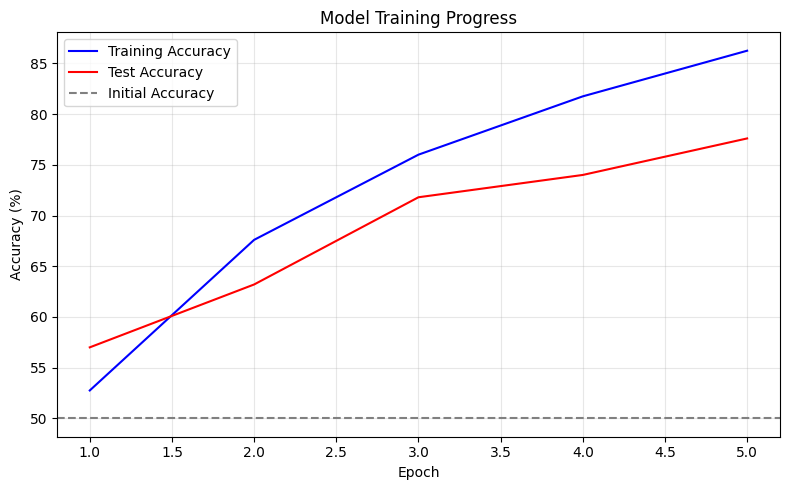

Accuracy Summary:
  Started at: 50.00% (untrained)
  Final test accuracy: 77.60%
  Total improvement: +27.60%


In [23]:
helper_utils.plot_training_history(history)

## 7 - Using PyTorch's Built-in Transformer Encoder
### 7.1 Creating a General-Purpose Encoder with PyTorch
Now that you understand the encoder architecture from building it yourself, let's leverage PyTorch's optimized implementation for a production-ready model. PyTorch provides `nn.TransformerEncoder` which handles all the complexity you've just implemented, but with additional optimizations for speed and memory efficiency.

#### A Versatile Encoder Design
The encoder we're building is designed to be versatile - it can be used standalone for tasks like classification, or as part of a larger encoder-decoder architecture for tasks like translation. This flexibility is achieved through a key design decision: **the encoder always returns both the encoded representation and the padding mask**.

**What is "Memory" in Transformer Context?**
In transformer terminology, "memory" refers to the encoded representation of the input sequence. It's called "memory" because:
- It contains all the learned contextual information from the input
- In encoder-decoder models, the decoder "remembers" and attends to this information
- Each position in the memory contains a rich, contextualized representation of the corresponding input token

#### The Encoder's Dual Output
Our encoder returns two crucial components:
1. **Memory** (`[batch_size, seq_len, d_model]`): The contextualized representations of all input tokens
2. **Padding Mask** (`[batch_size, seq_len]`): A boolean mask indicating which positions are padding

This dual output makes the encoder incredibly flexible:
- **For classification**: Use the memory with a pooling strategy and classification head
- **For translation**: Pass both memory and mask to a decoder
- **For sequence tagging**: Use the memory directly for token-level predictions

#### From Text to Encoded Representations: The Pipeline
Here's how our encoder processes text:
```
Input Text: "This movie is great"
         ↓
    [Tokenization]
         ↓
    Token IDs: [101, 2023, 3185, 2003, 2307, 0, 0]  (with padding)
         ↓
    [Token Embedding & Scaling]
         ↓
    [Add Positional Encoding]
         ↓
    [Create Padding Mask]
         ↓
    [Transformer Encoder Stack]
         ↓
    Outputs:
    - Memory: Contextualized representations for all positions
    - Padding Mask: [True, True, True, True, True, False, False]
```

#### Key Design Features
**Built-in Padding Support:**
- The encoder automatically creates padding masks from input token IDs
- Assumes padding token ID is 0 (standard convention)
- Ensures padding tokens don't influence the attention mechanism

**Architectural Parameters:**
- `vocab_size`: Size of the token vocabulary
- `d_model`: Dimension of token representations (256 by default)
- `nhead`: Number of attention heads for multi-perspective learning
- `num_layers`: Depth of the encoder stack
- `dim_feedforward`: Hidden dimension in feedforward networks
- `max_len`: Maximum sequence length supported
- `dropout`: Regularization to prevent overfitting

**Why This Design Matters:**
- **Flexibility**: Same encoder works for multiple downstream tasks
- **Efficiency**: Padding masks prevent unnecessary computation on padding tokens
- **Modularity**: Can easily plug this encoder into different architectures
- **Production-ready**: Uses PyTorch's optimized transformer implementation

In [24]:
class Encoder(nn.Module):
    """
    A modular Transformer-based Encoder for sequence representation.
    """
    def __init__(self, vocab_size, d_model=256, nhead=8, num_layers=3, 
                 dim_feedforward=512, max_len=100, dropout=0.1):
        """
        Initializes the encoder components including embeddings and transformer layers.

        Args:
            vocab_size (int): The total number of unique tokens in the input vocabulary.
            d_model (int): The dimensionality of the token embeddings and hidden states.
            nhead (int): The number of heads in the multi-head attention mechanism.
            num_layers (int): The number of transformer encoder layers to stack.
            dim_feedforward (int): The dimensionality of the internal feed-forward network.
            max_len (int): The maximum sequence length for positional encodings.
            dropout (float): The dropout probability used for regularization.
        """
        super().__init__()
        # Store internal model hyperparameters
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.nhead = nhead
        self.num_layers = num_layers
        self.dim_feedforward = dim_feedforward
        self.max_len = max_len
        self.dropout_value = dropout
        
        # Layer to map token indices to dense vectors
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=0)
        
        # Module to inject sequence order information into the embeddings
        self.pos_enc = PositionalEncoding(max_len, d_model)
        
        # Regularization layer applied to the input embeddings
        self.dropout = nn.Dropout(dropout)
         
        # Configuration for a single transformer encoder layer
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=dim_feedforward, 
            dropout=dropout, 
            batch_first=True 
        )
        # Stack of identical transformer encoder layers
        self.transformer_encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        
    def forward(self, src):
        """
        Processes the input sequence through the encoder layers.

        Args:
            src (Tensor): Input token indices of shape [batch_size, seq_len].

        Returns:
            memory (Tensor): The final encoded representations of shape [batch_size, seq_len, d_model].
            padding_mask (Tensor): A boolean mask indicating padding locations of shape [batch_size, seq_len].
        """
        # Generate a boolean mask to identify padding tokens for the attention mechanism
        padding_mask = create_padding_mask(src, pad_idx=0)
        
        # Transform indices to vectors, SCALE THEM, and combine them with positional information
        src = (self.token_emb(src) * math.sqrt(self.d_model)) + self.pos_enc(src)
        
        # Apply dropout to the sum of token and positional embeddings
        src = self.dropout(src)
        
        # Pass the input through the transformer stack using the padding mask to ignore pad tokens
        memory = self.transformer_encoder(src, src_key_padding_mask=padding_mask)
        
        # Provide both the encoded features and the mask for subsequent layers or decoders
        return memory, padding_mask

### 7.2 Encoder Output

In [25]:
# Initialize your encoder
encoder = Encoder(
    vocab_size=1000,
    d_model=128,
    nhead=8,
    num_layers=2,
    dim_feedforward=512,
    max_len=100,
    dropout=0.1
)
encoder.eval()

# Sample input
input_batch = torch.tensor([
    [2, 45, 23, 3, 0, 0],  # 4 tokens + 2 padding
    [2, 12, 89, 34, 56, 3]  # 6 tokens, no padding
])

print("Input:", input_batch)
print()

# Your encoder always returns both output and padding mask
with torch.no_grad():
    memory, padding_mask = encoder(input_batch)

print("Encoder returns:")
print(f"  memory shape: {memory.shape}")
print(f"  padding_mask shape: {padding_mask.shape}")
print(f"  padding_mask: {padding_mask}")
print()

Input: tensor([[ 2, 45, 23,  3,  0,  0],
        [ 2, 12, 89, 34, 56,  3]])

Encoder returns:
  memory shape: torch.Size([2, 6, 128])
  padding_mask shape: torch.Size([2, 6])
  padding_mask: tensor([[False, False, False, False,  True,  True],
        [False, False, False, False, False, False]])



### 7.3 Creating and Testing the Model

In [26]:
pytorch_model = Encoder(vocab_size=vocab_size, d_model=128, max_len = 256, num_layers = 2).to(device)

helper_utils.print_summary(pytorch_model, vocab_size=vocab_size)

Device available: cuda

Model moved to cuda
Ready for training!

MODEL SUMMARY
Model: Encoder
Vocabulary size: 5000
Embedding dimension: 128
Number of attention heads: 8
Total parameters: 1,036,544

The model is now ready to be trained!


In [27]:
# Test with a sample batch
sample_input, sample_labels = next(iter(train_loader))
sample_input = sample_input.to(device)

output = pytorch_model(sample_input)
print(f"\nTest forward pass:")
print(f"  Input shape: {sample_input.shape}")
print(f"  Output shape: {output[0].shape}")
print("  Model works! ✓")


Test forward pass:
  Input shape: torch.Size([32, 256])
  Output shape: torch.Size([32, 256, 128])
  Model works! ✓


### 7.4 The IMDB Classifier Using PyTorch Encoder

Now that we have our general-purpose Encoder, let's build a sentiment classifier for the IMDB dataset by adding a classification head on top.

#### Building a Task-Specific Model
Our approach is straightforward:
1. Use the Encoder to get contextualized representations (memory) of the input
2. Pool the sequence representations into a single vector
3. Add a linear classification head to predict sentiment

This modular design shows the power of the encoder architecture - we can reuse the same encoder for different tasks by simply changing what we put on top of it.

```
Input Tokens → Encoder → Memory & Mask → Mean Pooling → Linear Layer → Sentiment
                  ↓                           ↓                ↓
          Contextual Representations    Single Vector    Pos/Neg Score
```

For this classifier, we use mean pooling to aggregate the sequence (simple and effective for sentiment analysis) and a single linear layer for classification. The encoder does the heavy lifting of understanding context, while the classification head just needs to map the pooled representation to sentiment scores.

Let's implement this classifier:

In [28]:
class IMDBClassifierWithPytorchEncoder(nn.Module):
    """
    A sentiment classification model built upon a Transformer-based encoder.
    """
    def __init__(self, vocab_size, d_model=128, nhead=8, num_layers=2, 
                 dim_feedforward=512, max_len=256, dropout=0.1):
        """
        Initializes the classifier by configuring the encoder and the output layer.

        Args:
            vocab_size (int): The total number of unique tokens in the vocabulary.
            d_model (int): The dimensionality of the token embeddings and hidden states.
            nhead (int): The number of heads in the multi-head attention mechanism.
            num_layers (int): The number of transformer encoder layers to stack.
            dim_feedforward (int): The dimensionality of the internal feed-forward network.
            max_len (int): The maximum sequence length allowed for positional encodings.
            dropout (float): The dropout probability used for regularization.
        """
        super().__init__()
        
        # Core encoding module used to extract contextual features from sequence data
        self.encoder = Encoder(
            vocab_size=vocab_size,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dim_feedforward=dim_feedforward,
            max_len=max_len,
            dropout=dropout
        )
        
        # Linear projection layer used to map encoded features to class scores
        self.classifier = nn.Linear(d_model, 2)
        
    def forward(self, x):
        """
        Processes the input sequence through the encoder and classifier layers.

        Args:
            x (Tensor): Input tensor of token indices with shape [batch_size, seq_len].

        Returns:
            logits (Tensor): The raw classification scores with shape [batch_size, 2].
        """
        # Retrieve the encoded sequence representations and the associated padding mask
        memory, padding_mask = self.encoder(x)
        
        # Perform global average pooling across the sequence dimension to aggregate information
        pooled = memory.mean(dim=1)
        
        # Pass the aggregated representation through the linear classifier to get logits
        logits = self.classifier(pooled)
        
        # Return the final classification scores
        return logits

In [29]:
# Create the simple classifier
pytorch_model = IMDBClassifierWithPytorchEncoder(
    vocab_size=vocab_size,
    d_model=128,
    num_layers=2,
    max_len=256
).to(device)

helper_utils.print_summary(pytorch_model)

Device available: cuda

Model moved to cuda
Ready for training!

MODEL SUMMARY
Model: IMDBClassifierWithPytorchEncoder
Vocabulary size: 5000
Embedding dimension: 128
Number of attention heads: 8
Total parameters: 1,036,802

The model is now ready to be trained!


### 7.3 Training the PyTorch Model

In [30]:
# Loss function for classification
pytorch_criterion = nn.CrossEntropyLoss()

# Optimizer - Adam with learning rate 0.001
learning_rate = 0.001
pytorch_optimizer = optim.Adam(pytorch_model.parameters(), lr=learning_rate)

print("Training setup:")
print(f"  Loss function: CrossEntropyLoss")
print(f"  Optimizer: Adam")
print(f"  Learning rate: {learning_rate}")
print(f"  Batch size: {batch_size}")
print(f"  Training samples: {len(train_dataset)}")
print(f"  Test samples: {len(test_dataset)}")

Training setup:
  Loss function: CrossEntropyLoss
  Optimizer: Adam
  Learning rate: 0.001
  Batch size: 32
  Training samples: 2000
  Test samples: 500


In [31]:
# Now train
EPOCHS = 5
pytorch_history = helper_utils.train_model(
    pytorch_model,
    train_loader,
    test_loader,
    pytorch_optimizer,
    pytorch_criterion,
    num_epochs=EPOCHS
)

Training on cuda


Epoch 1/5 [Train]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1/5 [Test]:   0%|          | 0/16 [00:00<?, ?it/s]

  🎯 New best model! Test Acc: 64.40%
Epoch 1/5 Summary:
  Train - Loss: 0.6663, Acc: 59.65%
  Test   - Loss: 0.6309, Acc: 64.40%
--------------------------------------------------


Epoch 2/5 [Train]:   0%|          | 0/63 [00:00<?, ?it/s]

...

Epoch 4/5 [Test]:   0%|          | 0/16 [00:00<?, ?it/s]

  🎯 New best model! Test Acc: 78.20%
Epoch 4/5 Summary:
  Train - Loss: 0.3532, Acc: 84.15%
  Test   - Loss: 0.4767, Acc: 78.20%
--------------------------------------------------


Epoch 5/5 [Train]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 5/5 [Test]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 5/5 Summary:
  Train - Loss: 0.2754, Acc: 88.75%
  Test   - Loss: 0.5677, Acc: 73.20%
--------------------------------------------------

Training completed! Best model restored from epoch 4
Best Test Accuracy: 78.20%


### 7.4 Comparing Both Models

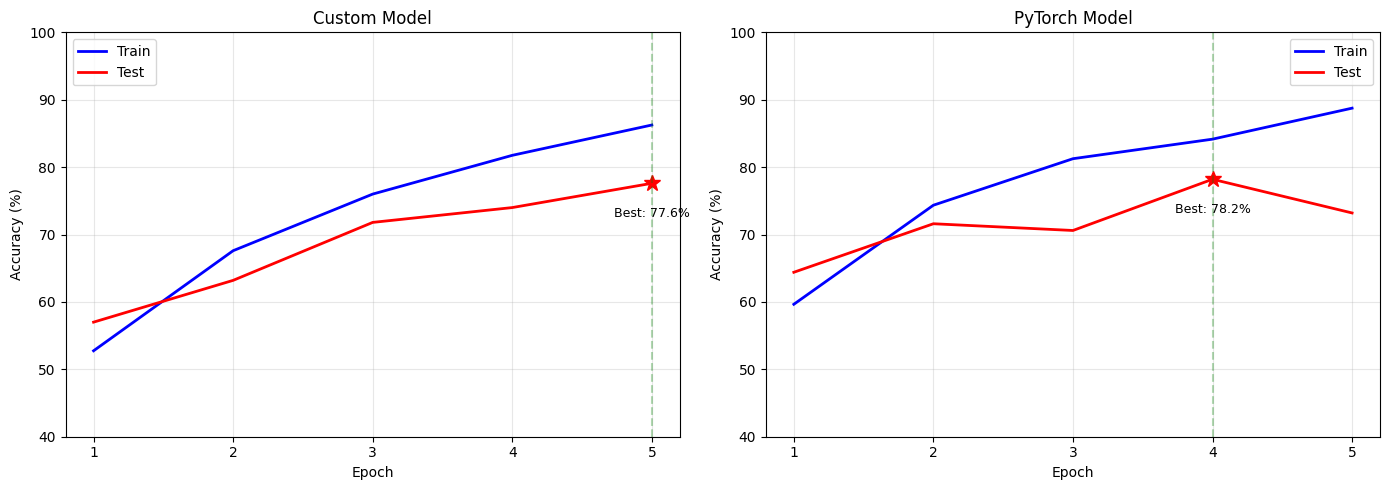


MODEL COMPARISON SUMMARY
Training Duration: 5 epochs

Custom Model:
  Architecture: Custom implementation
  Selected Model from Epoch: 5
  Selected Model Test Accuracy: 77.60%
  Selected Model Train Accuracy: 86.25%
  Convergence: Epoch 3

PyTorch Model:
  Architecture: Built-in implementation
  Selected Model from Epoch: 4
  Selected Model Test Accuracy: 78.20%
  Selected Model Train Accuracy: 84.15%
  (Final epoch accuracy was: 73.20%)
  Convergence: Epoch 2

------------------------------------------------------------
PERFORMANCE ANALYSIS
------------------------------------------------------------
Difference in selected model accuracy: +0.60%
Faster convergence: PyTorch Model (by 1 epochs)

------------------------------------------------------------
INTERPRETATION
------------------------------------------------------------
✓ Both models perform similarly! The implementations are comparable.

⚠️  Overfitting Analysis (for selected models):
  Custom Model: 8.7% gap (train-test) at

In [32]:
helper_utils.compare_models(history, pytorch_history)

### Model Performance Analysis with Best Epoch Selection

After implementing early stopping (selecting the best epoch rather than the final one), you can better compare both models' true performance:

#### The Impact of Early Stopping

**Custom Model:**
- Typically reaches best performance in later epochs (4-5)
- Train-test gap: ~8-10% (mild overfitting)
- Often continues improving throughout training

**PyTorch Model:**
- Usually peaks earlier (epochs 2-4)
- Train-test gap: Often very small or even negative (excellent generalization)
- Performance sometimes degrades after peaking

#### Performance Comparison

**The results are remarkably close** - across different runs, sometimes the custom model performs better, sometimes the PyTorch model does. The difference is typically within 1-2%, which is essentially statistical noise. This variability shows that:

- Both architectures have similar capacity for this task
- Random initialization and training dynamics affect final performance
- The IMDB sentiment task isn't complex enough to strongly differentiate the models

#### Why Different Stopping Points?

**Custom Model**: Less regularization allows continued learning
- Can extract more patterns from the data over time
- Risk of eventual overfitting

**PyTorch Model**: Heavy regularization creates an earlier peak
- Multiple dropout layers prevent overlearning
- Model finds its sweet spot faster but can degrade with too much training

#### Model Confidence Analysis

One consistent difference across runs:
- **Custom model**: Makes confident predictions (70-90% certainty)
- **PyTorch model**: More hesitant predictions (50-60% certainty)

This confidence gap persists regardless of which model achieves better accuracy, suggesting it's an inherent characteristic of the architectures rather than a performance indicator.

#### Key Insights

1. **Both approaches work**: The similar performance validates both implementations
2. **Early stopping matters more for regularized models**: PyTorch model benefits more from finding its optimal epoch
3. **Confidence ≠ Accuracy**: The custom model is more decisive but not necessarily more correct

#### The Bottom Line

With proper early stopping, both models achieve comparable performance (typically 73-76% test accuracy). The "winner" varies by run, indicating that:
- Architecture differences matter less than training dynamics for this task
- Both models are essentially solving the problem equally well
- The choice between them might depend on other factors (confidence requirements, training stability, etc.)

This demonstrates an important lesson: for many real-world tasks, simple and complex architectures can achieve similar results, and the best choice depends on your specific requirements beyond just accuracy.

## 8 - Testing Models with Real Text
### 8.1 Creating a Prediction Function
Let's create a function to predict sentiment from any text:

In [33]:
def predict_sentiment(text, model, tokenizer, device):
    """
    Performs sentiment inference on a single string input.

    Args:
        text (str): The raw input text string to be analyzed.
        model (nn.Module): The trained neural network model used for prediction.
        tokenizer (object): The tokenizer instance used to encode the text.
        device (str or torch.device): The computation hardware (e.g., 'cpu' or 'cuda').

    Returns:
        sentiment (str): A string label indicating the predicted class ("Positive" or "Negative").
        confidence (float): The probability score associated with the predicted class.
        probabilities (Tensor): The full probability distribution across all classes.
    """
    # Set the model to evaluation mode to disable layers like dropout
    model.eval()
    
    # Transform the raw text into a numerical sequence of indices
    encoded = tokenizer.encode(text, max_len=256)
    # Convert the list of indices into a batch-oriented LongTensor on the target device
    input_tensor = torch.LongTensor([encoded]).to(device)
    
    # Disable gradient calculation for efficient inference
    with torch.no_grad():
        # Pass the input tensor through the model to obtain raw output scores
        output = model(input_tensor)
        # Apply the softmax function to normalize outputs into a probability distribution
        probabilities = torch.softmax(output, dim=1)
        # Identify the class index with the highest score
        prediction = torch.argmax(output, dim=1)
    
    # Extract the probability value corresponding to the predicted class
    confidence = probabilities[0][prediction].item()
    # Map the predicted numerical index to a human-readable sentiment label
    sentiment = "Positive" if prediction.item() == 1 else "Negative"
    
    # Return the label, the confidence score, and the complete probability tensor
    return sentiment, confidence, probabilities[0]

In [34]:
# Test reviews
test_reviews = [
    "This movie was absolutely fantastic! I loved every minute of it.",
    "Terrible film. Complete waste of time. I want my money back.",
    "Not bad, but not great either. It was okay I guess.",
    "One of the best films I've ever seen. Brilliant acting and amazing story!",
    "Boring and predictable. I fell asleep halfway through."
]

print("="*60)
print("TESTING BOTH MODELS WITH SAMPLE REVIEWS")
print("="*60)

for i, review in enumerate(test_reviews, 1):
    print(f"\nReview {i}: \"{review[:50]}...\"" if len(review) > 50 else f"\nReview {i}: \"{review}\"")
    print("-"*40)
    
    # Test with encoder from scratch
    sentiment, confidence, probs = predict_sentiment(review, model, tokenizer, device)
    print(f"Encoder from Scratch: {sentiment} (confidence: {confidence:.2%})")
    print(f"  [Negative: {probs[0]:.3f}, Positive: {probs[1]:.3f}]")
    
    # Test with PyTorch implemented encoder
    sentiment_pt, confidence_pt, probs_pt = predict_sentiment(review, pytorch_model, tokenizer, device)
    print(f"PyTorch Implemented Encoder: {sentiment_pt} (confidence: {confidence_pt:.2%})")
    print(f"  [Negative: {probs_pt[0]:.3f}, Positive: {probs_pt[1]:.3f}]")

TESTING BOTH MODELS WITH SAMPLE REVIEWS

Review 1: "This movie was absolutely fantastic! I loved every..."
----------------------------------------
Encoder from Scratch: Positive (confidence: 99.90%)
  [Negative: 0.001, Positive: 0.999]
PyTorch Implemented Encoder: Positive (confidence: 54.96%)
  [Negative: 0.450, Positive: 0.550]

Review 2: "Terrible film. Complete waste of time. I want my m..."
----------------------------------------
Encoder from Scratch: Negative (confidence: 99.92%)
  [Negative: 0.999, Positive: 0.001]
PyTorch Implemented Encoder: Negative (confidence: 52.05%)
  [Negative: 0.520, Positive: 0.480]

Review 3: "Not bad, but not great either. It was okay I guess..."
----------------------------------------
Encoder from Scratch: Positive (confidence: 89.34%)
  [Negative: 0.107, Positive: 0.893]
PyTorch Implemented Encoder: Positive (confidence: 51.91%)
  [Negative: 0.481, Positive: 0.519]

Review 4: "One of the best films I've ever seen. Brilliant ac..."
--------------

## 9 - Conclusion
In this notebook, you successfully built a Transformer Encoder from scratch and applied it to sentiment analysis. You learned the fundamental components of the encoder architecture including multi-head attention, feed-forward networks, layer normalization, and residual connections.

By comparing the encoder built from scratch with PyTorch's built-in TransformerEncoder, you discovered that simpler architectures can often perform better on small datasets. The custom encoder from scratch achieved competitive accuracy despite having fewer parameters and layers than the PyTorch implemented encoder model.

The key takeaway is that understanding the architecture deeply by building it yourself gives you the intuition to make better design choices for your specific problem. You now have the foundation to experiment with more complex transformer architectures and apply them to various NLP tasks.